<a href="https://colab.research.google.com/github/TyrannosaurusR/Predicting-ozone-concentration-in-Kaohsiung-using-weather-factors/blob/main/%E6%95%B8%E5%AD%B8%E7%A7%91%E5%B1%95_OuO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Simport pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

In [ ]:
data = pd.read_csv('/content/info_del2.csv')
data.columns

Index(['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'O3', 'RH', 'THC'], dtype='object')

In [ ]:
## 將數據集拆成訓練集與測試集
train_data, test_data = train_test_split(data, random_state=0, train_size=0.8)

* [參考](https://matters.news/@CHWang/92854-machine-learning-linear-regression%E8%BF%B4%E6%AD%B8%E6%A8%A1%E5%9E%8B-%E5%BC%B7%E5%A4%A7%E7%9A%84sklearn-%E7%B0%A1%E5%96%AE%E7%B7%9A%E6%80%A7%E8%BF%B4%E6%AD%B8%E6%A8%A1%E5%9E%8B-%E5%A4%9A%E9%A0%85%E5%BC%8F%E8%BF%B4%E6%AD%B8%E6%A8%A1%E5%9E%8B-%E5%A4%9A%E5%85%83%E8%BF%B4%E6%AD%B8%E6%A8%A1%E5%9E%8B-%E5%AE%8C%E6%95%B4%E5%AF%A6%E4%BD%9C%E6%95%99%E5%AD%B8-bafyreidbro25dokrljhrdiwfsyc2gg345yiym2uirxu4l3nc6zbxntdaqq)

## 多元線性回歸

In [ ]:
# x_train = train_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
x_train = train_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
y_train = train_data[['O3']].to_numpy()
# x_test = test_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
x_test = test_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
y_test = test_data[['O3']].to_numpy()

In [ ]:
## 訓練與建構迴歸模型
regressor = LinearRegression()
regressor.fit(x_train, y_train)

## 計算出截距值與係數值
w_0 = regressor.intercept_
w_1 = regressor.coef_

print('Interception : ', w_0)
print('Coeficient : ', w_1)

## 迴歸模型的準確度
score = regressor.score(x_test, y_test)
# print("MAE = {:.3f}".format(mean_absolute_error(y_test, regressor.predict(x_test))))
print('Score: ', score)
print('Accuracy: ' + str(score*100) + '%')

Interception :  [41.53528598]
Coeficient :  [[ 0.83232381 -0.39820921  1.39835235 -1.75526439 -0.34127122  3.37512627]]
Score:  0.6582188846882266
Accuracy: 65.82188846882266%


## 線性回歸

In [ ]:
x = 'THC' ## 可替換成其他 feature, i.e., 'AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC'
x_train = train_data[[x]].to_numpy()
y_train = train_data[['O3']].to_numpy()
x_test = test_data[[x]].to_numpy()
y_test = test_data[['O3']].to_numpy()

In [ ]:
## 訓練與建構迴歸模型
regressor = LinearRegression()
regressor.fit(x_train, y_train)

## O3 = w_1*x+w_0

## 計算出截距值與係數值
w_0 = regressor.intercept_
w_1 = regressor.coef_

print('Interception : ', w_0)
print('Coeficient : ', w_1)

## 迴歸模型的準確度
score = regressor.score(x_test, y_test)
print('Score: ', score)
print('Accuracy: ' + str(score*100) + '%')

Interception :  [98.76092727]
Coeficient :  [[-30.74753607]]
Score:  0.12150582304930135
Accuracy: 12.150582304930136%


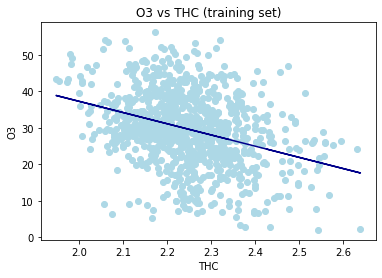

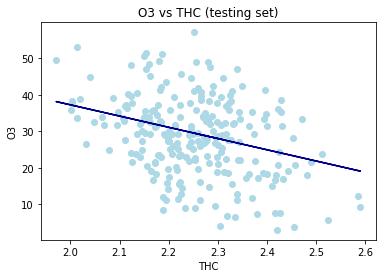

In [ ]:
## 視覺化迴歸模型與訓練集的關聯
plt.scatter(x_train, y_train, color = 'lightblue')
plt.plot(x_train, regressor.predict(x_train), color = 'darkblue')
plt.title('O3 vs '+str(x)+' (training set)')
plt.xlabel(str(x))
plt.ylabel("O3")
plt.show()

## 視覺化迴歸模型與測試集的關聯
plt.scatter(x_test, y_test, color = 'lightblue')
plt.plot(x_test, regressor.predict(x_test), color = 'darkblue')
plt.title('O3 vs '+str(x)+' (testing set)')
plt.xlabel(str(x))
plt.ylabel("O3")
plt.show()

## 多項式回歸

In [ ]:
x = 'NOx' ## 可替換成其他 feature, i.e., 'AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC'
x_train = train_data[[x]].to_numpy()
y_train = train_data[['O3']].to_numpy()
x_test = test_data[[x]].to_numpy()
y_test = test_data[['O3']].to_numpy()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 3) ## 可以替換最高次方
x_poly = poly_reg.fit_transform(x_train)
lin_reg_2 = LinearRegression().fit(x_poly, y_train)
lin_reg_2.coef_

array([[ 0.00000000e+00, -4.12135345e-01, -1.87832284e-02,
         2.67295599e-04]])

In [ ]:
lin_reg_2.intercept_

array([44.49493995])

In [ ]:
## 使用訓練集資料來訓練(擬和)迴歸模型
regressor = make_pipeline(PolynomialFeatures(3), LinearRegression())  ## 可以替換最高次方
regressor.fit(x_train, y_train)

## 迴歸模型的準確度
score = regressor.score(x_test, y_test)
print('Score: ', score)
print('Accuracy: ' + str(score*100) + '%')

Score:  0.3758568921367307
Accuracy: 37.58568921367307%


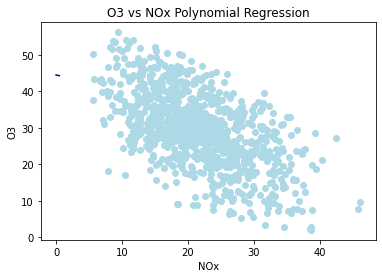

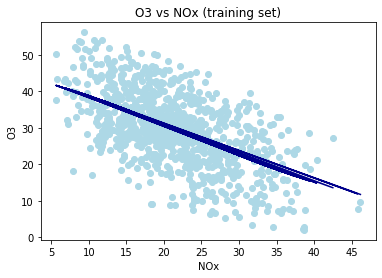

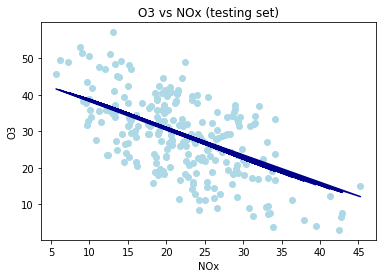

In [ ]:
## 視覺化迴歸模型
plt.scatter(x_train, y_train, color = 'lightblue')
myline = np.linspace(0, 0.5, 1000)
myline = np.reshape(myline, (1000, 1))
plt.plot(myline, regressor.predict(myline), color = 'darkblue')
plt.title('O3 vs '+str(x)+' Polynomial Regression')
plt.xlabel(str(x))
plt.ylabel("O3")
plt.show()

## 視覺化迴歸模型與訓練集的關聯
plt.scatter(x_train, y_train, color = 'lightblue')
plt.plot(x_train, regressor.predict(x_train), color = 'darkblue')
plt.title('O3 vs '+str(x)+' (training set)')
plt.xlabel(str(x))
plt.ylabel("O3")
plt.show()

## 視覺化迴歸模型與測試集的關聯
plt.scatter(x_test, y_test, color = 'lightblue')
plt.plot(x_test, regressor.predict(x_test), color = 'darkblue')
plt.title('O3 vs '+str(x)+' (testing set)')
plt.xlabel(str(x))
plt.ylabel("O3")
plt.show()

## 決策樹

In [ ]:
param_grid = {'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None]}
tree_model = GridSearchCV(DecisionTreeRegressor(random_state=0),
                          cv = 5,
                          scoring = 'neg_mean_squared_error',
                          param_grid = param_grid)
tree_model.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=0),
             param_grid={'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None]},
             scoring='neg_mean_squared_error')

In [ ]:
pred = tree_model.predict(x_test)
print("MAE = {:.3f}".format(mean_absolute_error(y_test, pred)))
print("R^2 = {:.5f}".format(r2_score(y_test, pred)))

MAE = 7.103
R^2 = 0.36022


## 類神經網路

In [ ]:
# x_train = train_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
x_train = train_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
y_train = train_data[['O3']].to_numpy()
# x_test = test_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
x_test = test_data[['AMB_TEMP', 'NMHC', 'NO2', 'NOx', 'RH', 'THC']].to_numpy()
y_test = test_data[['O3']].to_numpy()

In [ ]:
# build the model!
model = Sequential()
model.add(Dense(5, input_shape=(x_train.shape[1],), activation='linear')) # (features,)
model.add(Dense(50, activation='linear'))
model.add(Dense(20, activation='linear'))
model.add(Dense(20, activation='relu'))
model.add(Dense(1, activation='linear')) # output node
model.summary() # see what your model looks like

# compile the model
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# early stopping callback
es = EarlyStopping(monitor='val_loss',
                   mode='min',
                   patience=50,
                   restore_best_weights = True)

# fit the model!
# attach it to a new variable called 'history' in case
# to look at the learning curves
history = model.fit(x_train, y_train,
                    validation_data = (x_test, y_test),
                    callbacks=[es],
                    epochs=100, ## 可以調整
                    batch_size=8, ## 8, 16, 32, 64
                    verbose=1)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 5)                 35        
                                                                 
 dense_1 (Dense)             (None, 50)                300       
                                                                 
 dense_2 (Dense)             (None, 20)                1020      
                                                                 
 dense_3 (Dense)             (None, 20)                420       
                                                                 
 dense_4 (Dense)             (None, 1)                 21        
                                                                 
Total params: 1,796
Trainable params: 1,796
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
120/120 [==============================] -

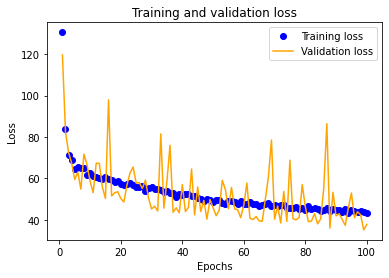

In [ ]:
# let's see the training and validation accuracy by epoch
history_dict = history.history
loss_values = history_dict['loss'] # you can change this
val_loss_values = history_dict['val_loss'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'orange', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

8/8 [==============================] - 0s 2ms/step


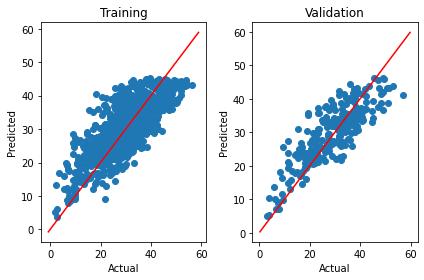

In [ ]:
# scatterplot of actual vs. pred
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# this makes the individual subplots
# Training Results
axes[0].scatter(x=y_train, y=model.predict(x_train)) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted",  fontsize=10)
axes[0].set_title("Training")
# add 45 deg line
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')
# Validation Results
axes[1].scatter(x=y_test, y=model.predict(x_test)) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted",  fontsize=10)
axes[1].set_title("Validation")
# add 45 deg line
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# show the plot
plt.show()

In [ ]:
pred = model.predict(x_test)
print("MAE = {:.3f}".format(mean_absolute_error(y_test, pred)))
print("R^2 = {:.5f}".format(r2_score(y_test, pred)))

8/8 [==============================] - 0s 2ms/step
MAE = 4.891
R^2 = 0.67257
